<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>FoodHub: Customer Demand and Restaurant Analysis</font></center>
<center><font size=6>UT Austin AIML Program — Exploratory Data Analysis Project</font></center>
<center><font size=6><b>Prepared by: Usiere Uko</b></font></center>

<div align="center">

<img src="https://images.pexels.com/photos/12725455/pexels-photo-12725455.jpeg?auto=compress&cs=tinysrgb&w=1200"
width="600"/>

</div>

# Project Python Foundations: FoodHub Data Analysis

## Executive Summary

This project analyzes customer ordering behavior, restaurant demand patterns, cuisine preferences, and delivery performance for FoodHub, a food aggregation platform operating in New York. Through exploratory data analysis, the project identifies operational trends and business insights that can help improve customer experience, restaurant partnerships, and delivery efficiency.

## Problem Statement

FoodHub aims to better understand customer ordering patterns, restaurant demand, and delivery performance in order to improve operational efficiency and customer satisfaction.

## Objectives

- Analyze customer ordering behavior and restaurant demand patterns
- Identify the most popular cuisines and restaurants
- Explore delivery and food preparation trends
- Generate actionable business insights and recommendations

## Data Description

The dataset contains customer order information, restaurant details, cuisine types, order costs, customer ratings, food preparation times, and delivery times collected from FoodHub’s food delivery platform.

## Data Dictionary

The dataset includes variables related to:

- Customer and restaurant identifiers
- Cuisine types and order costs
- Weekday and weekend order activity
- Customer ratings
- Food preparation and delivery times

### Importing the required libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 65.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**:
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset

In [3]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Read the data
df = pd.read_csv('/content/drive/MyDrive/foodhub_order.csv')

## Data Overview

### Viewing the first 5 rows of the dataset

In [5]:
# Returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### Checking the shape of the dataset

In [7]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 1898 rows and 9 columns.


### Checking the data types of the columns for the dataset.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


### Checking for missing values

In [9]:
# Checking for missing values in the data
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0



*   There are no missing values in the dataset

### Statistical summary of the data

In [10]:
# Getting the summary statistics of the numerical data
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


- The average order cost is approximately \$16.50, with most orders ranging between \$12 and \$22, indicating moderate customer spending patterns.

- Food preparation and delivery times show relatively low variation, with average preparation and delivery times of about 27 minutes and 24 minutes respectively.

- The maximum food preparation and delivery times are 35 minutes and 33 minutes, suggesting that most orders are completed within a fairly consistent operational timeframe.

### Orders that are not rated

In [11]:
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188




*   736 orders were not rated

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### Exploring all the variables and their distributions.

#### Order ID

In [12]:
# check unique order ID
df['order_id'].nunique()

1898



*   There are 1898 unique orders

#### Customer ID

In [13]:
There# check unique customer ID
df['customer_id'].nunique()

1200



*   There are 1200 unique customers

#### Restaurant name

In [14]:
# check unique Restaurant Name
df['restaurant_name'].nunique()

178

*   There are 178 unique restaurants

#### Cuisine type

In [15]:
# Check unique cuisine type
df['cuisine_type'].nunique()

14



*   There are 14 unique cuisine types

<Axes: xlabel='cuisine_type', ylabel='count'>

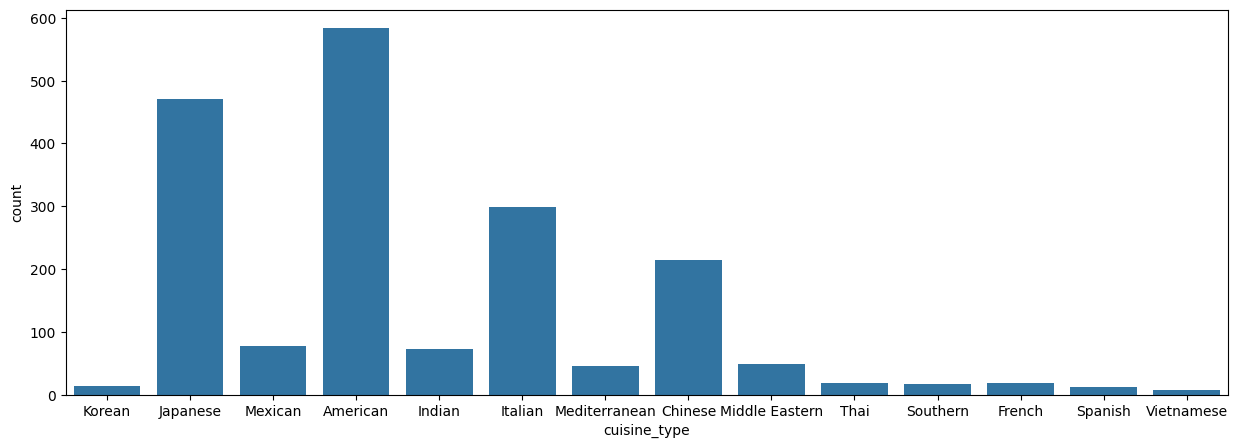

In [17]:
plt.figure(figsize = (15,5))
sns.countplot(data = df, x = 'cuisine_type') ## Create a countplot for cuisine type.



*   American, Japanese, Italian, and Chinese cuisines are the most popular choices.


#### Cost of the order

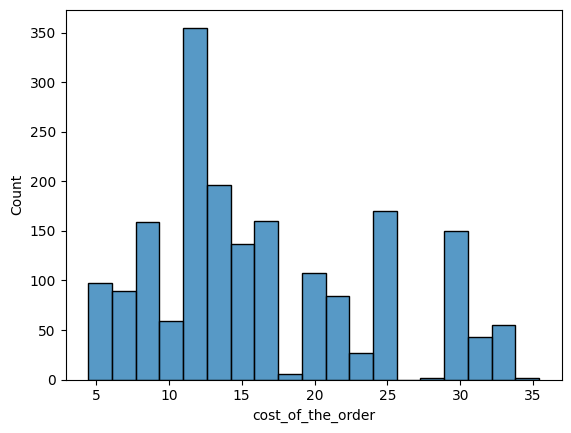

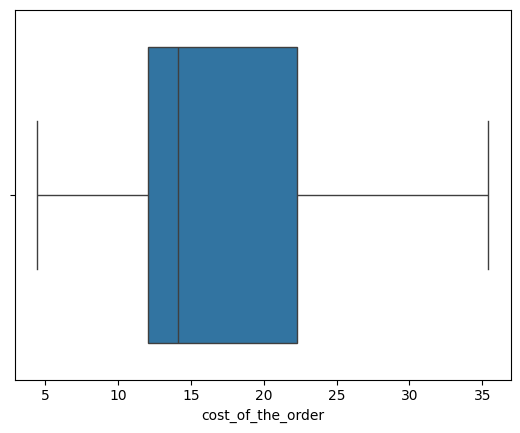

In [16]:
sns.histplot(data=df,x='cost_of_the_order') ## Histogram for the cost of order
plt.show()
sns.boxplot(data=df,x='cost_of_the_order') ## Boxplot for the cost of order
plt.show()



- Most customers placed orders costing between \$11 and \$13, while the median cost of order is around \$14.


#### Day of the week

In [18]:
# # Check the unique values
df['day_of_the_week'].unique()

array(['Weekend', 'Weekday'], dtype=object)

<Axes: xlabel='day_of_the_week', ylabel='count'>

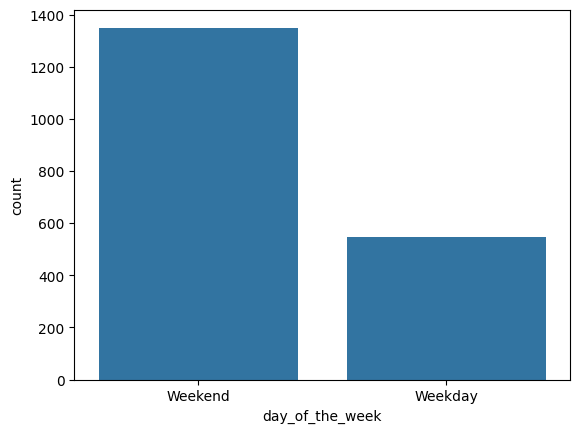

In [19]:
sns.countplot(data = df, x = 'day_of_the_week')



*   Most customers place orders on weekends compared to week days.


#### Rating

In [20]:
# Check the unique values
df['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

<Axes: xlabel='rating', ylabel='count'>

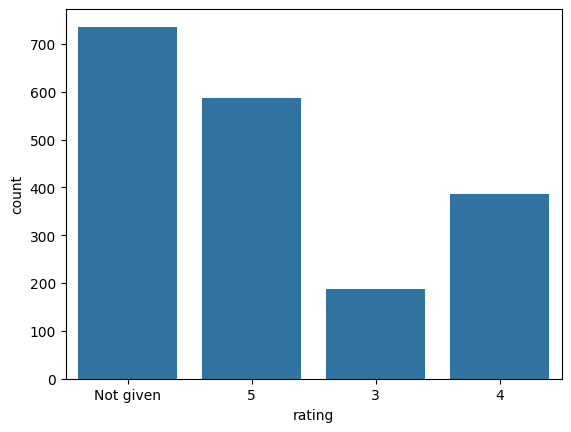

In [21]:
sns.countplot(data = df, x = 'rating')



*   Most customers did not provide a rating
*   Among those who did, 5-star ratings were the most frequent.



#### Food Preparation time

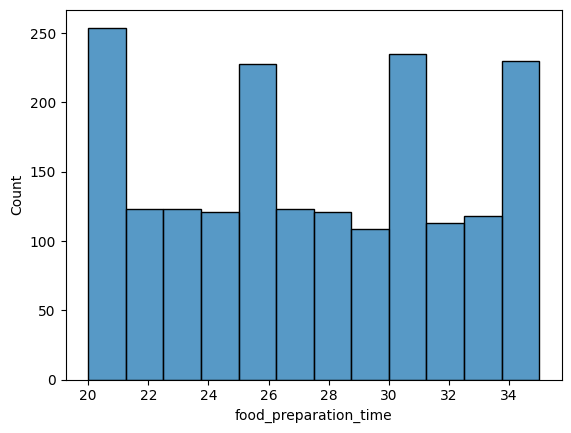

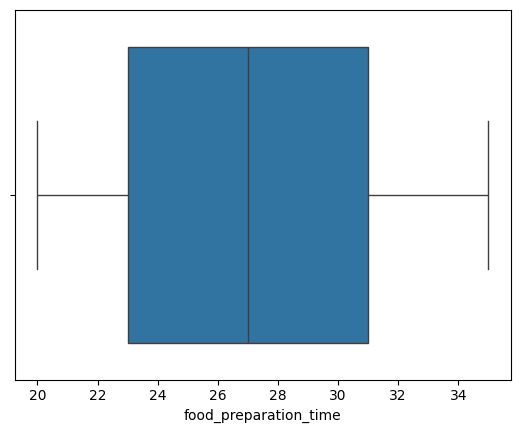

In [22]:
sns.histplot(data=df,x='food_preparation_time')
plt.show()
sns.boxplot(data=df,x='food_preparation_time')
plt.show()



*   The most frequent food preparation times cluster around 20, 26, 30, and 34 minutes while the median time is 27 minutes.



#### Delivery time

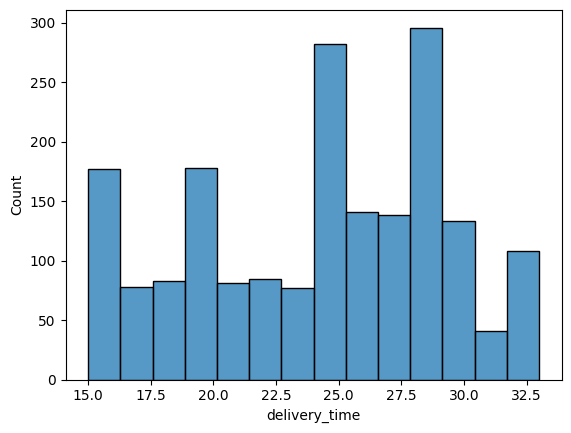

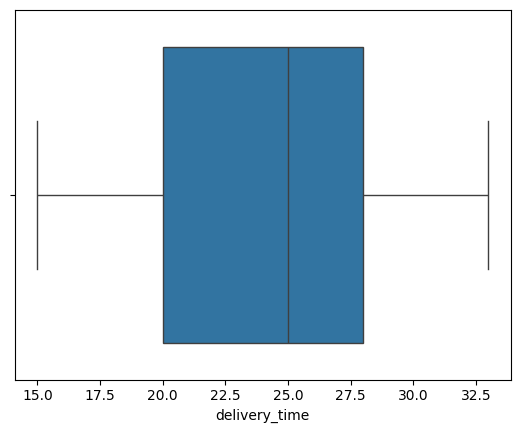

In [23]:
sns.histplot(data=df,x='delivery_time')
plt.show()
sns.boxplot(data=df,x='delivery_time')
plt.show()



*   The most frequent delivery times cluster around 25 and 29 minutes while the median delivery time is 25 minutes.



### Top 5 restaurants in terms of the number of orders received

In [24]:
# Getting the top 5 restaurants with highest number of orders
df['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68




*   The top 5 restaurants in terms of the number of orders received are Shake Shack (219), The Meatball Shop (32), Blue Ribbon Sushi (119), Blue Ribbon Fried Chicken (96) and Parm (68)



### The most popular cuisine on weekends

In [25]:
# Getting most popular cuisine on weekends
df_weekend = df[df['day_of_the_week'] == 'Weekend']
df_weekend['cuisine_type'].value_counts()

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Middle Eastern,32
Mediterranean,32
Thai,15




*   The most popular cuisine on weekends are American, Japanese, Italian, Chinese and Mexican



### Percentage of the orders cost more than 20 dollars

In [26]:
# Get orders that cost above 20 dollars
df_greater_than_20 = df[df['cost_of_the_order']>20]

# Calculate the number of total orders where the cost is above 20 dollars
print('The number of total orders that cost above 20 dollars is:', df_greater_than_20.shape[0])

# Calculate percentage of such orders in the dataset
percentage = (df_greater_than_20.shape[0] / df.shape[0]) * 100

print("Percentage of orders above 20 dollars:", round(percentage, 2), '%')

The number of total orders that cost above 20 dollars is: 555
Percentage of orders above 20 dollars: 29.24 %


### The mean order delivery time

In [27]:
# Get the mean delivery time
mean_del_time = df['delivery_time'].mean()

print('The mean delivery time for this dataset is', round(mean_del_time, 2), 'minutes')

The mean delivery time for this dataset is 24.16 minutes


### The top 5 most frequent customers

In [28]:
# Get the counts of  each customer_id
df['customer_id'].value_counts().head(5)

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7




*   Top 5 most frequent customers are customers ID 52832, 47440, 83287, 250494 and 259341

### Multivariate Analysis

#### Cuisine vs Cost of the order

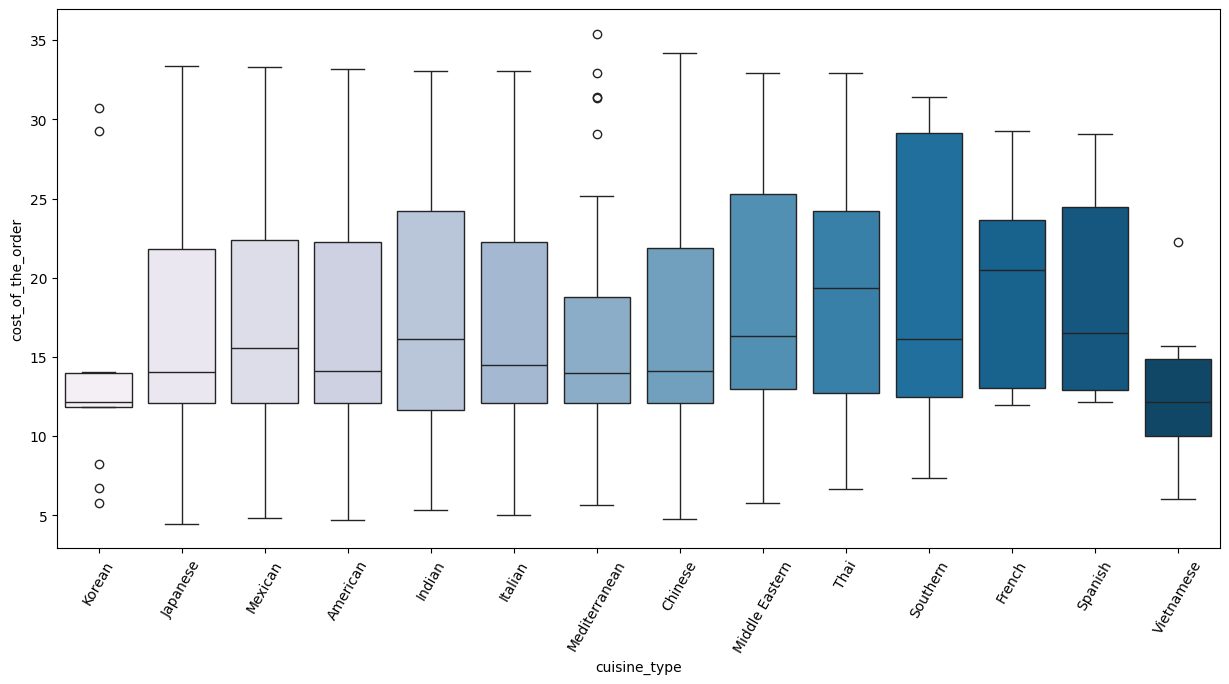

In [29]:
# Relationship between cost of the order and cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = df, palette = 'PuBu', hue = "cuisine_type")
plt.xticks(rotation = 60)
plt.show()



*   The French and Thai cuisines have the highest median cost, while Korean and Vietnamese cuisine orders are the least expensive.



#### Cuisine vs Food Preparation time

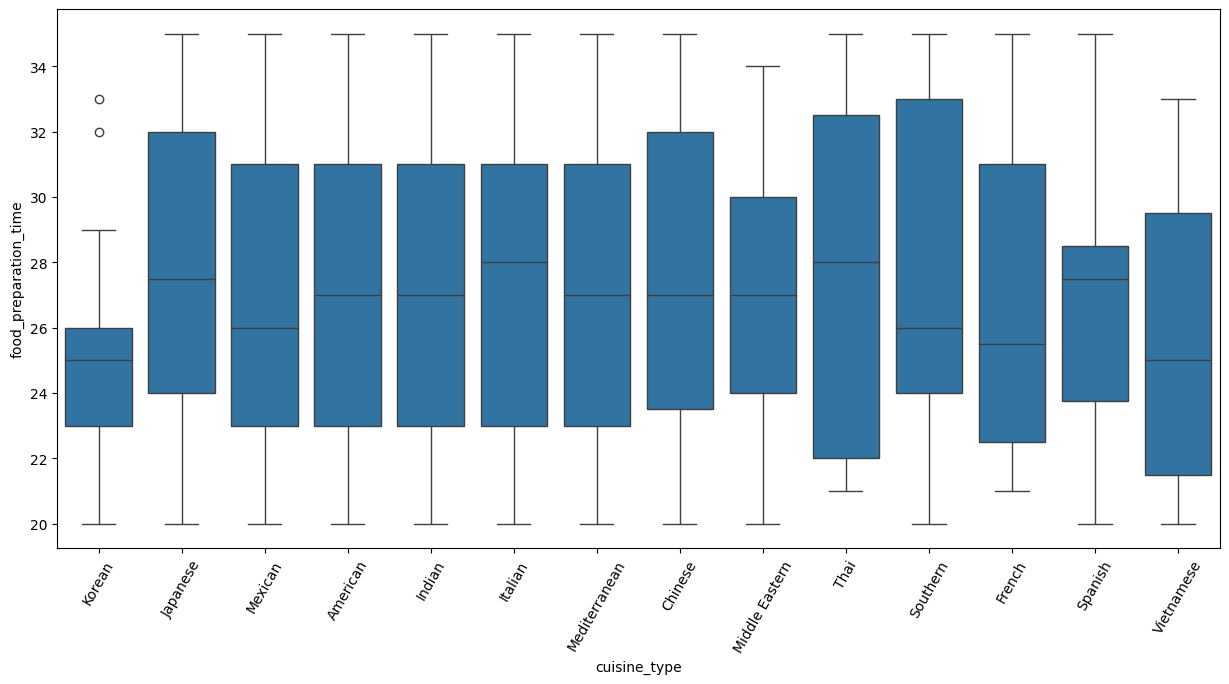

In [30]:
# Relationship between food preparation time and cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x='cuisine_type', y='food_preparation_time', data=df)
plt.xticks(rotation = 60)
plt.show()



*   Thai, Italian, Spanish and Japanese cuisines tend to require the longest food preparation times, while Vietnamese and Korean cuisines has the shortest median time.




#### Day of the Week vs Delivery time

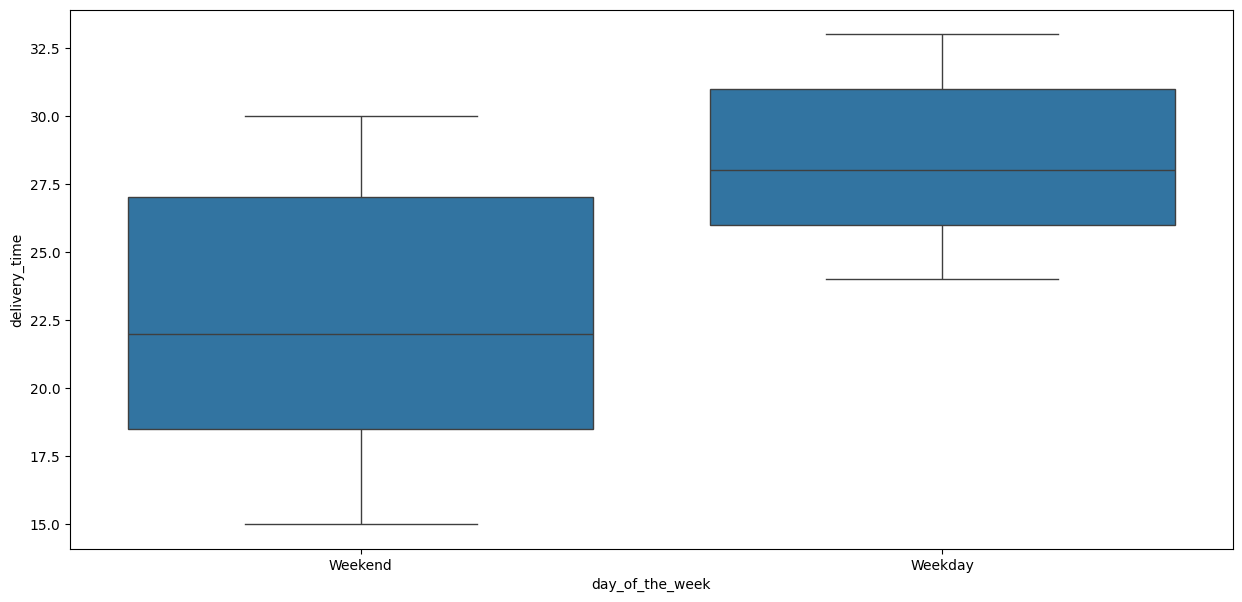

In [31]:
# Relationship between day of the week and delivery time
plt.figure(figsize=(15,7))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.show()



*   Week day delivery times have a median of about 27.5 minutes, which is higher that the weekend median delivery time of about 22 minutes.



#### Revenue generated by the restaurants.

In [33]:
df.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending = False).head(14)

,cost_of_the_order
restaurant_name,
Shake Shack,3579.53
The Meatball Shop,2145.21
Blue Ribbon Sushi,1903.95
Blue Ribbon Fried Chicken,1662.29
Parm,1112.76
RedFarm Broadway,965.13
RedFarm Hudson,921.21
TAO,834.50
Han Dynasty,755.29



*   The top 5 restaurants in terms of revenue are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken and Parm



#### Rating vs Delivery time

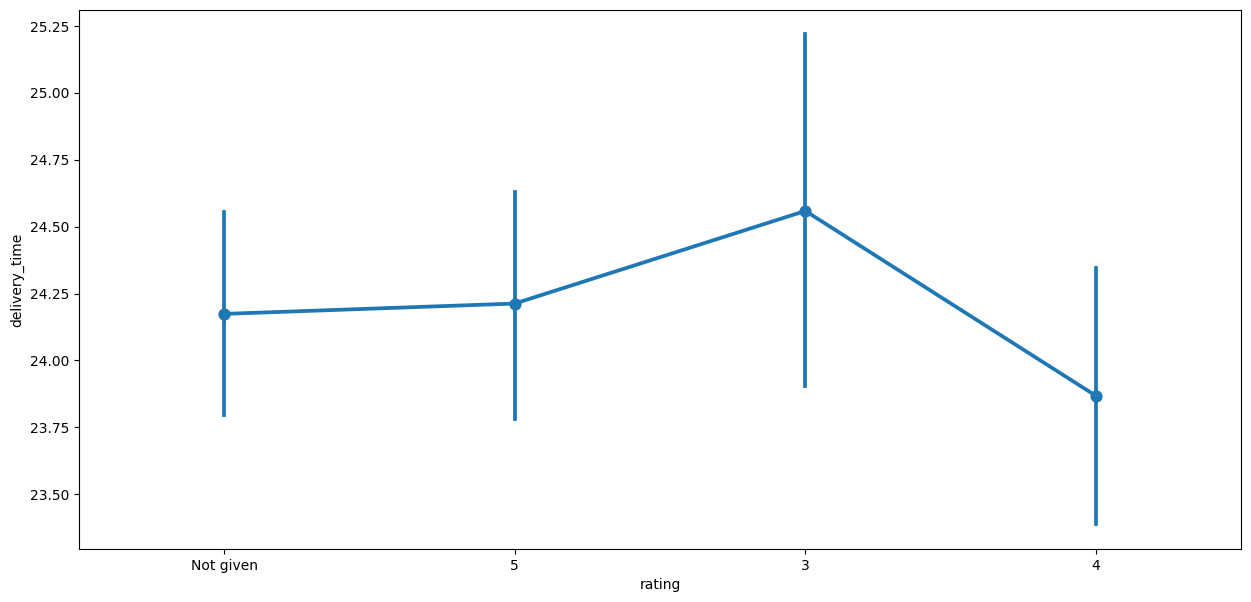

In [34]:
# Relationship between rating and delivery time
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'delivery_time', data = df)
plt.show()



*   The highest delivery time of about 24.5 minutes has the lowest rating of 3 while the lowest delivery time of about 23.8 minutes has a rating of 4.


#### Rating vs Food preparation time

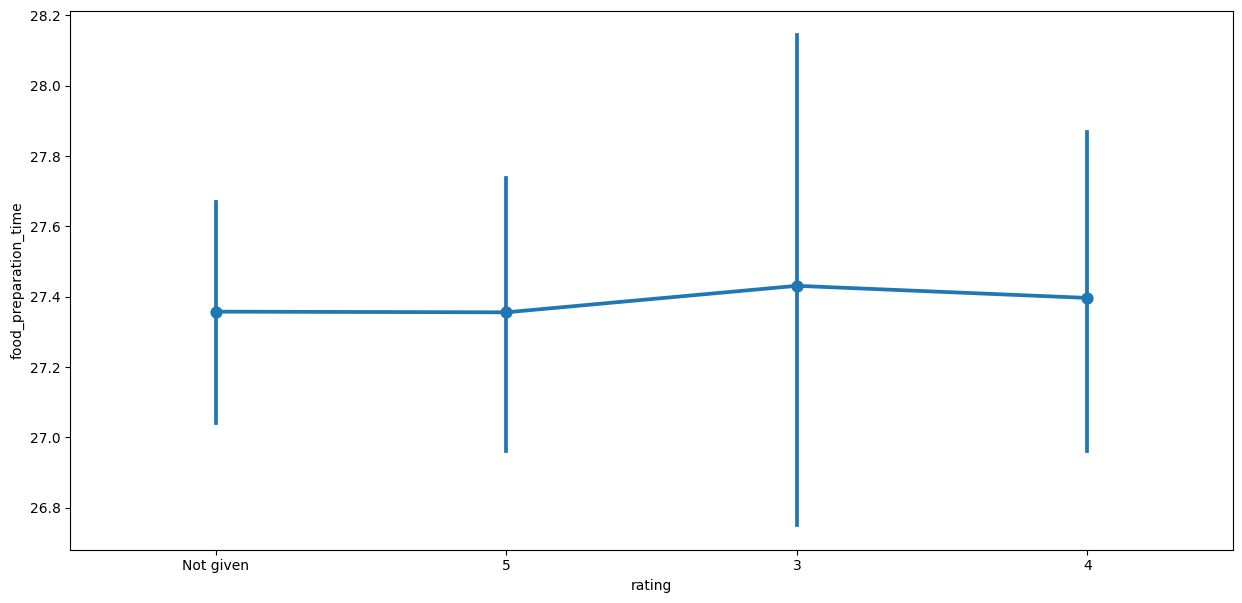

In [35]:
# Relationship between rating and food preparation time
plt.figure(figsize=(15, 7))
sns.pointplot(x='rating', y='food_preparation_time', data=df)
plt.show()



*   The highest food preparation time of above 27.4 minutes has the lowest rating of 3 while the lowest food preparation time of below 27.4 minutes has the highest rating of 5 and no rating.



#### Rating vs Cost of the order

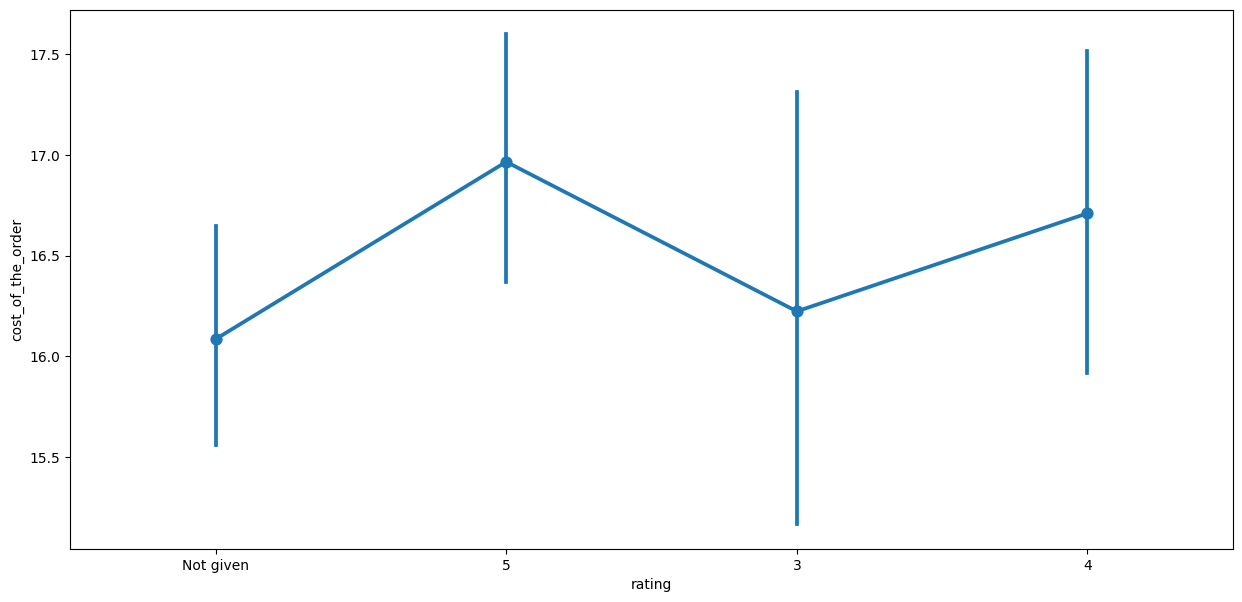

In [36]:
# Relationship between rating and cost of the order
plt.figure(figsize=(15, 7))
sns.pointplot(x='rating', y='cost_of_the_order', data=df)
plt.show()



*   The most expensive order of about \$17 has the highest rating of 5 while the least expensive order of about \$16 has no rating.



#### Correlation among variables

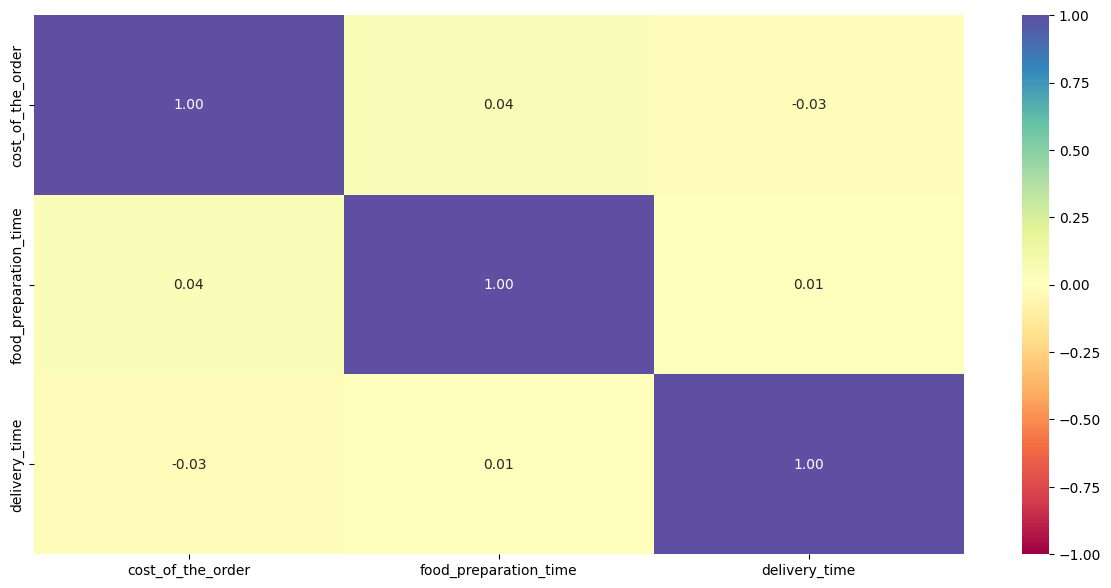

In [38]:
# lot the heatmap
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(15, 7))
sns.heatmap(df[col_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()



- The correlation matrix indicates very weak relationships among order cost, food preparation time, and delivery time.

- Order cost shows almost no correlation with food preparation or delivery time, suggesting that higher-priced orders do not necessarily take longer to prepare or deliver.

- Food preparation time and delivery time also exhibit negligible correlation, indicating that delivery performance is largely independent of restaurant preparation time.



### Restaurants receiving more than 50 customer ratings with average ratings greater than 4

In [39]:
# Filter the rated restaurants
df_rated = df[df['rating'] != 'Not given'].copy()

# Converting rating column from object to integer
df_rated['rating'] = df_rated['rating'].astype('int')

# Creating a dataframe that contains the restaurant names with their rating counts
df_rating_count = df_rated.groupby(['restaurant_name'])['rating'].count().sort_values(ascending = False).reset_index()
df_rating_count.head()

,restaurant_name,rating
0,Shake Shack,133
1,The Meatball Shop,84
2,Blue Ribbon Sushi,73
3,Blue Ribbon Fried Chicken,64
4,RedFarm Broadway,41





- Shake Shack, The Meatball Shop, Blue Ribbon Sushi and Blue Ribbon Fried Chicken received more than 50 customer ratings



In [40]:
# Get the restaurant names that have rating count more than 50
rest_names = df_rating_count[df_rating_count['rating'] > 50]['restaurant_name']

# Filter to get the data of restaurants that have rating count more than 50
df_mean_4 = df_rated[df_rated['restaurant_name'].isin(rest_names)].copy()

# Group the restaurant names with their ratings and find the mean rating of each restaurant
df_mean_4_rating = df_mean_4.groupby(['restaurant_name'])['rating'].mean().sort_values(ascending=False).reset_index().dropna()

# filter for average rating greater than 4
df_avg_rating_greater_than_4 = df_mean_4_rating[df_mean_4_rating['rating'] > 4] \
    .sort_values(by='rating', ascending=False) \
    .reset_index(drop=True)

df_avg_rating_greater_than_4

,restaurant_name,rating
0,The Meatball Shop,4.511905
1,Blue Ribbon Fried Chicken,4.328125
2,Shake Shack,4.278195
3,Blue Ribbon Sushi,4.219178




- The Meatball Shop, Blue Ribbon Fried Chicken, Shake Shack, and Blue Ribbon Sushi received average ratings above 4 while also meeting the minimum ratings threshold.



### Net Revenue Analysis

In [41]:
#function to determine the revenue
def compute_rev(x):
    if x > 20:
        return x*0.25
    elif x > 5:
        return x*0.15
    else:
        return x*0

df['Revenue'] = df['cost_of_the_order'].apply(compute_rev) ## Write the apprpriate column name to compute the revenue
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,Revenue
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,7.6875
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,1.8120
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,1.8345
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,7.3000
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,1.7385


In [42]:
# get the total revenue and print it
total_rev = df['Revenue'].sum() ## Write the appropriate function to get the total revenue
print('The net revenue is around', round(total_rev, 2), 'dollars')

The net revenue is around 6166.3 dollars




- FoodHub generates revenue by charging different commission rates based on the value of customer orders.

- Orders above \$20 contribute more significantly to revenue due to the higher commission rate of 25%.

- Lower-value orders between \$5 and \$20 generate comparatively lower revenue at a 15% commission rate.

### Percentage of Orders Delivered in More Than 60 Minutes

In [43]:
# Calculate total delivery time and add a new column to the dataframe df to store the total delivery time
df['total_time'] = df['food_preparation_time'] + df['delivery_time']


## Percentage of orders that have more than 60 minutes of total delivery time
perc_over_60 = (df[df['total_time'] > 60].shape[0] / df.shape[0]) * 100
print("Percentage of orders with more than 60 minutes total delivery time:", round(perc_over_60, 2), "%")




Percentage of orders with more than 60 minutes total delivery time: 10.54 %


### Delivery Time Analysis: Weekdays vs Weekends

In [44]:
# Get the mean delivery time on weekdays and print it
print('The mean delivery time on weekdays is around',
      round(df[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean()),
     'minutes')


## Get the mean delivery time on weekends and print it
print('The mean delivery time on weekends is around',
      round(df[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean()),
     'minutes')




The mean delivery time on weekdays is around 28 minutes
The mean delivery time on weekends is around 22 minutes


## Conclusions and Recommendations

### Conclusions

- American, Japanese, Italian, and Chinese cuisines emerged as the most popular customer choices, while French and Thai cuisines showed higher average order values.

- Most customer orders ranged between \$11 and \$13, indicating moderate spending behavior across the platform.

- Orders were more frequent on weekends, while weekday deliveries generally experienced longer delivery times.

- Faster food preparation and delivery times were associated with higher customer ratings and improved customer satisfaction.

- The analysis highlights opportunities to improve delivery efficiency, customer engagement, and overall operational performance.

### Recommendations

- Focus marketing and partnership efforts on high-demand cuisines while promoting premium and budget-friendly cuisine categories strategically.

- Encourage higher order values through targeted promotions, combo offers, and upselling strategies.

- Improve operational efficiency by optimizing rider allocation, reducing preparation delays, and monitoring delivery bottlenecks.

- Increase customer engagement by encouraging post-delivery ratings and leveraging highly rated restaurants in promotional campaigns.

- Adopt a data-driven approach to continuously monitor customer behavior, restaurant performance, and delivery operations.

---